# Experiment 10: Medical Image Denoising using Convolutional Autoencoders
**Student Roll Number:** `CH.SC.U4AIE24015`  
**Environment:** Google Colab (Python 3, GPU / CPU)  
**File Name:** `Exp_10_Medical_Image_Denoising_Autoencoder.ipynb`

### Objective & Description
Convolutional Autoencoder for image noise suppression on PneumoniaMNIST / Medical MNIST data with visual comparison of reconstructions.


### Convolutional Autoencoder Denoising


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 3.9 MB/s eta 0:00:00
Student Roll Number: CH.SC.U4AIE24015
Experiment 10: Convolutional Autoencoder for Medical Image Denoising


100%|██████████| 4.17M/4.17M [00:04<00:00, 1.01MB/s]


Loaded PneumoniaMNIST successfully from MedMNIST.
Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - loss: 0.6688 - val_loss: 0.6533
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6438 - val_loss: 0.6438
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6399 - val_loss: 0.6417
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6384 - val_loss: 0.6404
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6374 - val_loss: 0.6399
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6368 - val_loss: 0.6388
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6363 - val_loss: 0.6383
Epoch 8/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6358 - val_loss: 0.6379
Epoch 9/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6355 - val_loss: 0.6377
Epoch 10/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6352 - val_loss: 0.6374

[Roll No: CH.SC.U4AIE24015] Test Reconstruction Loss: 0.6374


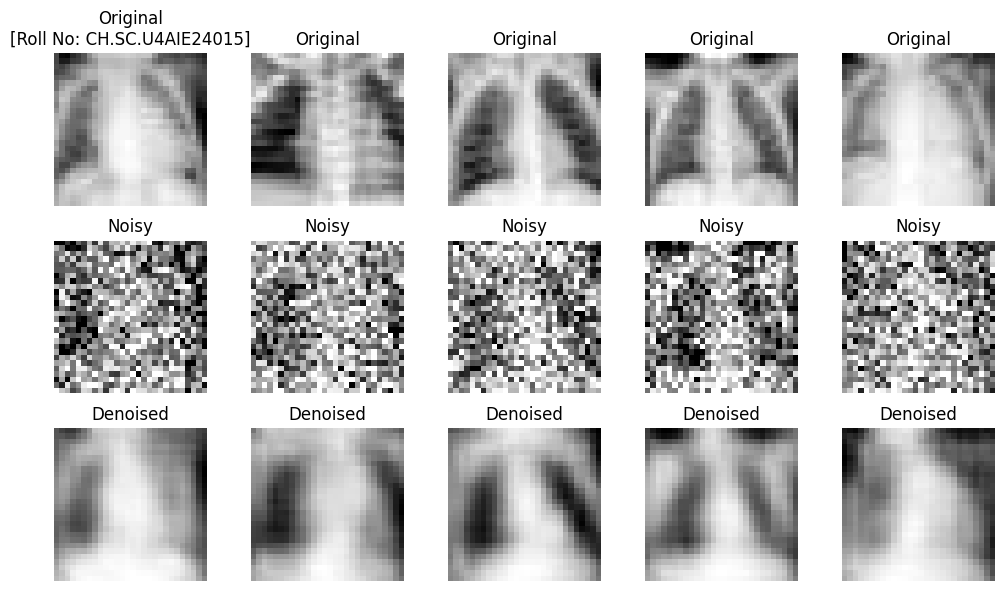

In [1]:
# Experiment 10: Denoising and Dimensionality Reduction for Medical MNIST
# File: Exp_10_Medical_Image_Denoising_Autoencoder.ipynb
# Student Roll Number: CH.SC.U4AIE24015

!pip install -q medmnist

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("=" * 60)
print("Student Roll Number: CH.SC.U4AIE24015")
print("Experiment 10: Convolutional Autoencoder for Medical Image Denoising")
print("=" * 60)

# Load PneumoniaMNIST or fallback to MNIST
try:
    import medmnist
    from medmnist import PneumoniaMNIST
    dataset_train = PneumoniaMNIST(split="train", download=True)
    dataset_test = PneumoniaMNIST(split="test", download=True)
    X_train = dataset_train.imgs.astype("float32") / 255.0
    X_test = dataset_test.imgs.astype("float32") / 255.0
    print("Loaded PneumoniaMNIST successfully from MedMNIST.")
except Exception as e:
    print("Note: Falling back to MNIST dataset.")
    (X_train, _), (X_test, _) = keras.datasets.mnist.load_data()
    X_train = X_train.astype("float32") / 255.0
    X_test = X_test.astype("float32") / 255.0

# Add channel dimension
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

# Add random Gaussian noise and clip to [0, 1]
noise_factor = 0.3
X_train_noisy = np.clip(X_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_train.shape), 0.0, 1.0)
X_test_noisy = np.clip(X_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_test.shape), 0.0, 1.0)

# Build Convolutional Autoencoder
autoencoder = keras.Sequential([
    # Encoder
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2), padding="same"),
    layers.Conv2D(8, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2), padding="same"), # Bottleneck

    # Decoder
    layers.Conv2D(8, (3, 3), activation="relu", padding="same"),
    layers.UpSampling2D((2, 2)),
    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.UpSampling2D((2, 2)),
    layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same")
])

autoencoder.compile(optimizer="adam", loss="binary_crossentropy")
autoencoder.fit(
    X_train_noisy, X_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test_noisy, X_test),
    verbose=1
)

# Predict denoised test images
denoised_images = autoencoder.predict(X_test_noisy[:5], verbose=0)
test_loss = autoencoder.evaluate(X_test_noisy, X_test, verbose=0)
print(f"\n[Roll No: CH.SC.U4AIE24015] Test Reconstruction Loss: {test_loss:.4f}")

# Display Original, Noisy, and Denoised Images
n = 5
plt.figure(figsize=(10, 6))
for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(X_test[i].squeeze(), cmap="gray")
    plt.title(f"Original\n[Roll No: CH.SC.U4AIE24015]" if i == 0 else "Original")
    plt.axis("off")

    # Noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(X_test_noisy[i].squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Denoised
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(denoised_images[i].squeeze(), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()
